# 🌿 Plant Part & Species Classification
### Hierarchical Classification: Plant Part → Species
**Model:** MobileNetV2 (Transfer Learning)

**Pipeline:**
1. ขั้นตอนที่ 1: ทำนายส่วนของพืช (`bark`, `flower`, `fruit`, `leaf`)
2. ขั้นตอนที่ 2: ทำนายชนิดของพืช (3 สายพันธุ์)

**โครงสร้างข้อมูล (Google Drive):**
```
planttest/
├── bark/
│   ├── species_1/ (100 images)
│   ├── species_2/ (100 images)
│   └── species_3/ (100 images)
├── flower/
├── fruit/
└── leaf/
```

## 📦 Step 1: Install & Import Libraries

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model

from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.19.0
GPU available: False


## 📂 Step 2: Mount Google Drive & Set Paths

In [5]:
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# ✏️ แก้ไข path ให้ตรงกับตำแหน่ง planttest ใน Google Drive
# ============================================================
BASE_DIR = '/content/drive/MyDrive/planttest'

PLANT_PARTS = ['bark', 'flower', 'fruit', 'leaf']

# ตรวจสอบโครงสร้างโฟลเดอร์
print('📁 Dataset Structure:')
species_names = None
for part in PLANT_PARTS:
    part_path = os.path.join(BASE_DIR, part)
    if os.path.exists(part_path):
        species = sorted(os.listdir(part_path))
        species = [s for s in species if os.path.isdir(os.path.join(part_path, s))]
        if species_names is None:
            species_names = species
        print(f'  📂 {part}/ → {species}')
        for sp in species:
            sp_path = os.path.join(part_path, sp)
            img_count = len([f for f in os.listdir(sp_path) if f.lower().endswith(('.jpg','.jpeg','.png','.jfif'))])
            print(f'       └── {sp}: {img_count} images')
    else:
        print(f'  ❌ {part}/ NOT FOUND')

print(f'\n✅ Species detected: {species_names}')

Mounted at /content/drive
📁 Dataset Structure:
  📂 bark/ → ['Nokyung', 'Nonsi', 'Taku']
       └── Nokyung: 100 images
       └── Nonsi: 100 images
       └── Taku: 100 images
  📂 flower/ → ['Nokyung', 'Nonsi', 'Taku']
       └── Nokyung: 100 images
       └── Nonsi: 100 images
       └── Taku: 100 images
  📂 fruit/ → ['Nokyung', 'Nonsi', 'Taku']
       └── Nokyung: 100 images
       └── Nonsi: 100 images
       └── Taku: 100 images
  📂 leaf/ → ['Nokyung', 'Nonsi', 'Taku']
       └── Nokyung: 100 images
       └── Nonsi: 100 images
       └── Taku: 100 images

✅ Species detected: ['Nokyung', 'Nonsi', 'Taku']


## ⚙️ Step 3: Configuration

In [6]:
# ============================================================
# CONFIG — แก้ไขได้ตามต้องการ
# ============================================================
IMG_SIZE      = (224, 224)   # MobileNetV2 input size
BATCH_SIZE    = 32
EPOCHS_STAGE1 = 30           # Train top layers only
EPOCHS_STAGE2 = 50           # Fine-tune with unfrozen layers
LEARNING_RATE = 1e-3
FINE_TUNE_LR  = 1e-5
VAL_SPLIT     = 0.2
TEST_SPLIT    = 0.1
SEED          = 42
SAVE_DIR      = '/content/drive/MyDrive/plant_models'

os.makedirs(SAVE_DIR, exist_ok=True)

NUM_PARTS   = len(PLANT_PARTS)          # 4
NUM_SPECIES = len(species_names)        # 3

print(f'Parts  : {NUM_PARTS}  → {PLANT_PARTS}')
print(f'Species: {NUM_SPECIES} → {species_names}')
print(f'Image size: {IMG_SIZE}, Batch: {BATCH_SIZE}')

Parts  : 4  → ['bark', 'flower', 'fruit', 'leaf']
Species: 3 → ['Nokyung', 'Nonsi', 'Taku']
Image size: (224, 224), Batch: 32


## 🗂️ Step 4: Prepare Datasets
สร้าง flat dataset สำหรับ **Part Classifier** และ per-part datasets สำหรับ **Species Classifier**

In [7]:
import shutil, random
from sklearn.model_selection import train_test_split

PREPARED_DIR = '/content/plant_data'

def collect_images(base_dir, parts, species_names):
    """Returns list of (image_path, part_label, species_label)"""
    data = []
    for part in parts:
        for species in species_names:
            folder = os.path.join(base_dir, part, species)
            if not os.path.exists(folder):
                print(f'⚠️  Missing: {folder}')
                continue
            imgs = [f for f in os.listdir(folder)
                    if f.lower().endswith(('.jpg','.jpeg','.png','.jfif'))]
            for img in imgs:
                data.append((os.path.join(folder, img), part, species))
    return data

def prepare_flat_dataset(data, out_dir, label_fn, split=(0.7, 0.2, 0.1)):
    """Copy images into train/val/test folders by label."""
    random.seed(SEED)
    random.shuffle(data)
    n = len(data)
    tr = int(n * split[0])
    vl = int(n * (split[0] + split[1]))
    splits = {'train': data[:tr], 'val': data[tr:vl], 'test': data[vl:]}

    for subset, items in splits.items():
        for src_path, part, species in items:
            label = label_fn(part, species)
            dst_dir = os.path.join(out_dir, subset, label)
            os.makedirs(dst_dir, exist_ok=True)
            fname = f'{part}_{species}_{os.path.basename(src_path)}'
            shutil.copy2(src_path, os.path.join(dst_dir, fname))
    print(f'✅ Dataset prepared at: {out_dir}')
    for subset in ['train','val','test']:
        labels = os.listdir(os.path.join(out_dir, subset))
        print(f'   {subset}: {len(splits[subset])} images, classes={labels}')

# Collect all images
all_data = collect_images(BASE_DIR, PLANT_PARTS, species_names)
print(f'\nTotal images found: {len(all_data)}')

# ── 1. Part Classifier dataset ──────────────────────────────
PART_DATA_DIR = os.path.join(PREPARED_DIR, 'part_classifier')
if not os.path.exists(PART_DATA_DIR):
    prepare_flat_dataset(all_data, PART_DATA_DIR, label_fn=lambda p, s: p)
else:
    print(f'Part dataset already exists at {PART_DATA_DIR}')

# ── 2. Species Classifier dataset (one per part) ─────────────
for part in PLANT_PARTS:
    part_data = [(path, p, sp) for path, p, sp in all_data if p == part]
    sp_dir = os.path.join(PREPARED_DIR, f'species_{part}')
    if not os.path.exists(sp_dir):
        prepare_flat_dataset(part_data, sp_dir, label_fn=lambda p, s: s)
    else:
        print(f'Species/{part} dataset already exists')


Total images found: 1200
✅ Dataset prepared at: /content/plant_data/part_classifier
   train: 840 images, classes=['leaf', 'bark', 'fruit', 'flower']
   val: 240 images, classes=['leaf', 'bark', 'fruit', 'flower']
   test: 120 images, classes=['leaf', 'bark', 'fruit', 'flower']
✅ Dataset prepared at: /content/plant_data/species_bark
   train: 210 images, classes=['Taku', 'Nonsi', 'Nokyung']
   val: 60 images, classes=['Taku', 'Nonsi', 'Nokyung']
   test: 30 images, classes=['Taku', 'Nonsi', 'Nokyung']
✅ Dataset prepared at: /content/plant_data/species_flower
   train: 210 images, classes=['Taku', 'Nonsi', 'Nokyung']
   val: 60 images, classes=['Taku', 'Nonsi', 'Nokyung']
   test: 30 images, classes=['Taku', 'Nonsi', 'Nokyung']
✅ Dataset prepared at: /content/plant_data/species_fruit
   train: 210 images, classes=['Taku', 'Nonsi', 'Nokyung']
   val: 60 images, classes=['Taku', 'Nonsi', 'Nokyung']
   test: 30 images, classes=['Taku', 'Nonsi', 'Nokyung']
✅ Dataset prepared at: /content/p

## 🔧 Step 5: Data Generators with Augmentation

In [8]:
def make_generators(data_dir, batch_size=BATCH_SIZE, img_size=IMG_SIZE):
    train_gen = ImageDataGenerator(
        preprocessing_function=tf.keras.applications.mobilenet_v3.preprocess_input,
        rotation_range=20,
        width_shift_range=0.15,
        height_shift_range=0.15,
        zoom_range=0.2,
        horizontal_flip=True,
        brightness_range=[0.8, 1.2],
        fill_mode='nearest'
    )
    val_test_gen = ImageDataGenerator(
        preprocessing_function=tf.keras.applications.mobilenet_v3.preprocess_input
    )

    train = train_gen.flow_from_directory(
        os.path.join(data_dir, 'train'),
        target_size=img_size, batch_size=batch_size,
        class_mode='categorical', seed=SEED
    )
    val = val_test_gen.flow_from_directory(
        os.path.join(data_dir, 'val'),
        target_size=img_size, batch_size=batch_size,
        class_mode='categorical', seed=SEED
    )
    test = val_test_gen.flow_from_directory(
        os.path.join(data_dir, 'test'),
        target_size=img_size, batch_size=batch_size,
        class_mode='categorical', seed=SEED, shuffle=False
    )
    return train, val, test

# Create part classifier generators
part_train, part_val, part_test = make_generators(PART_DATA_DIR)
print(f'Part classes: {part_train.class_indices}')

# Create species generators per part
species_gens = {}
for part in PLANT_PARTS:
    sp_dir = os.path.join(PREPARED_DIR, f'species_{part}')
    tr, vl, te = make_generators(sp_dir)
    species_gens[part] = {'train': tr, 'val': vl, 'test': te}
    print(f'Species/{part} classes: {tr.class_indices}')

Found 836 images belonging to 4 classes.
Found 239 images belonging to 4 classes.
Found 118 images belonging to 4 classes.
Part classes: {'bark': 0, 'flower': 1, 'fruit': 2, 'leaf': 3}
Found 210 images belonging to 3 classes.
Found 60 images belonging to 3 classes.
Found 30 images belonging to 3 classes.
Species/bark classes: {'Nokyung': 0, 'Nonsi': 1, 'Taku': 2}
Found 208 images belonging to 3 classes.
Found 60 images belonging to 3 classes.
Found 30 images belonging to 3 classes.
Species/flower classes: {'Nokyung': 0, 'Nonsi': 1, 'Taku': 2}
Found 206 images belonging to 3 classes.
Found 59 images belonging to 3 classes.
Found 30 images belonging to 3 classes.
Species/fruit classes: {'Nokyung': 0, 'Nonsi': 1, 'Taku': 2}
Found 210 images belonging to 3 classes.
Found 60 images belonging to 3 classes.
Found 30 images belonging to 3 classes.
Species/leaf classes: {'Nokyung': 0, 'Nonsi': 1, 'Taku': 2}


## 🏗️ Step 6: Build MobileNetV2 Model

In [9]:
def build_mobilenet_model(num_classes, model_name='model'):
    """
    MobileNetV2 Transfer Learning Model
    Stage 1: Freeze base → train head only
    Stage 2: Unfreeze top layers → fine-tune
    """
    base = MobileNetV3Large(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
    )
    base.trainable = False  # Freeze for Stage 1

    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu', name='fc1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = models.Model(inputs, outputs, name=model_name)
    return model, base

def get_callbacks(model_name, save_dir=SAVE_DIR):
    return [
        ModelCheckpoint(
            filepath=os.path.join(save_dir, f'{model_name}_best.keras'),
            monitor='val_accuracy', save_best_only=True, verbose=1
        ),
        EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=1)
    ]

def train_two_stage(model, base_model, train_gen, val_gen, model_name,
                    epochs1=EPOCHS_STAGE1, epochs2=EPOCHS_STAGE2,
                    unfreeze_from=-20):
    """
    Two-stage training:
    Stage 1: Train head only (frozen base)
    Stage 2: Fine-tune top layers of base
    """
    # ── Stage 1 ──────────────────────────────
    print(f'\n🔵 Stage 1: Training head layers ({model_name})')
    model.compile(
        optimizer=optimizers.Adam(LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    hist1 = model.fit(
        train_gen, validation_data=val_gen,
        epochs=epochs1,
        callbacks=get_callbacks(f'{model_name}_s1')
    )

    # ── Stage 2: Fine-tune ────────────────────
    print(f'\n🟠 Stage 2: Fine-tuning ({model_name})')
    base_model.trainable = True
    # Freeze all except last `|unfreeze_from|` layers
    for layer in base_model.layers[:unfreeze_from]:
        layer.trainable = False

    model.compile(
        optimizer=optimizers.Adam(FINE_TUNE_LR),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    hist2 = model.fit(
        train_gen, validation_data=val_gen,
        epochs=epochs2,
        callbacks=get_callbacks(f'{model_name}_s2')
    )

    # Save final model
    save_path = os.path.join(SAVE_DIR, f'{model_name}_final.keras')
    model.save(save_path)
    print(f'✅ Model saved: {save_path}')
    return hist1, hist2

print('Model builder ready ✅')

Model builder ready ✅


## 🌿 Step 7: Train Part Classifier (bark / flower / fruit / leaf)

In [10]:
part_model, part_base = build_mobilenet_model(NUM_PARTS, 'part_classifier')
part_model.summary()

part_hist1, part_hist2 = train_two_stage(
    part_model, part_base,
    part_train, part_val,
    model_name='part_classifier'
)

# Evaluate on test set
print('\n📊 Part Classifier — Test Evaluation:')
part_loss, part_acc = part_model.evaluate(part_test)
print(f'   Loss: {part_loss:.4f} | Accuracy: {part_acc:.4f}')

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "part_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 960)            │         3,840 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,248,260 (12.39 MB)

 Trainable params: 249,476 (974.52 KB)

 Non-trainable params: 2,998,784 (11.44 MB)


🔵 Stage 1: Training head layers (part_classifier)
Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6415 - loss: 0.9814
Epoch 1: val_accuracy improved from None to 0.92469, saving model to /content/drive/MyDrive/plant_models/part_classifier_s1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/plant_models/part_classifier_s1_best.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.7895 - loss: 0.5868 - val_accuracy: 0.9247 - val_loss: 0.2265 - learning_rate: 0.0010
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9368 - loss: 0.1797
Epoch 2: val_accuracy improved from 0.92469 to 0.94979, saving model to /content/drive/MyDrive/plant_models/part_classifier_s1_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/plant_models/part_classifier_s1_best.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.9330 - loss: 0.1874 - val_accuracy: 0.9498 - val_loss: 0.1404 - learning_rate: 0.0010
Epoch 3/30
27/27 ━━━━━━━━━━━━━

## 🌱 Step 8: Train Species Classifiers (one per part)

In [11]:
species_models = {}

for part in PLANT_PARTS:
    print(f'\n{'='*60}')
    print(f'  Training Species Classifier for: {part.upper()}')
    print(f'{'='*60}')

    model, base = build_mobilenet_model(NUM_SPECIES, f'species_{part}')

    h1, h2 = train_two_stage(
        model, base,
        species_gens[part]['train'],
        species_gens[part]['val'],
        model_name=f'species_{part}'
    )

    # Evaluate
    loss, acc = model.evaluate(species_gens[part]['test'])
    print(f'  [{part}] Test Accuracy: {acc:.4f}')

    species_models[part] = {
        'model': model,
        'class_indices': species_gens[part]['train'].class_indices,
        'hist': (h1, h2),
        'test_acc': acc
    }

print('\n✅ All species models trained!')


  Training Species Classifier for: BARK

🔵 Stage 1: Training head layers (species_bark)
Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4776 - loss: 1.2497
Epoch 1: val_accuracy improved from None to 0.95000, saving model to /content/drive/MyDrive/plant_models/species_bark_s1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/plant_models/species_bark_s1_best.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.6190 - loss: 0.8836 - val_accuracy: 0.9500 - val_loss: 0.2827 - learning_rate: 0.0010
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9351 - loss: 0.1904
Epoch 2: val_accuracy did not improve from 0.95000
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.9190 - loss: 0.2087 - val_accuracy: 0.9500 - val_loss: 0.1927 - learning_rate: 0.0010
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9007 - loss: 0.1884
Epoch 3: val_accuracy did not improve from 0.95000
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9286 - loss

## 📊 Step 9: Plot Training History

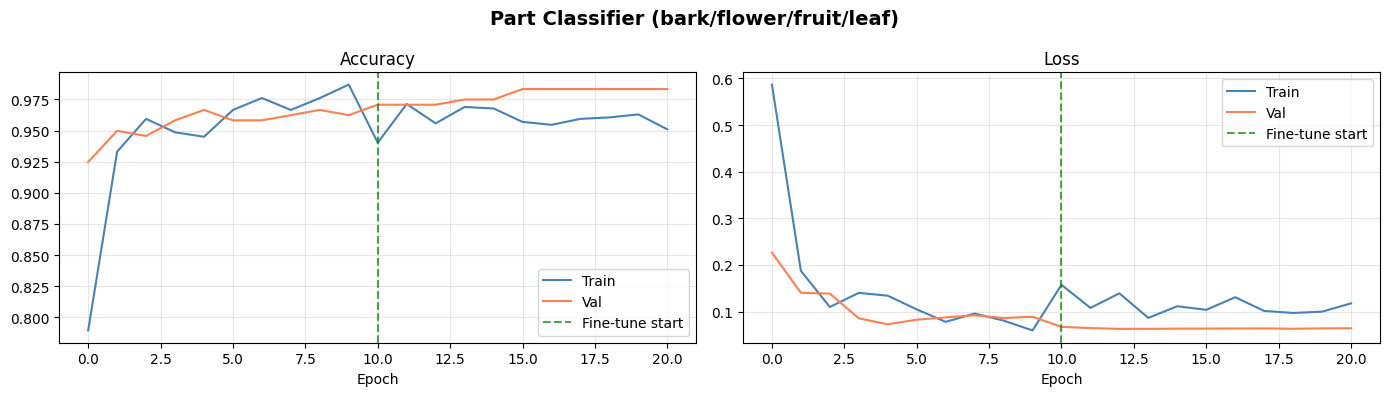

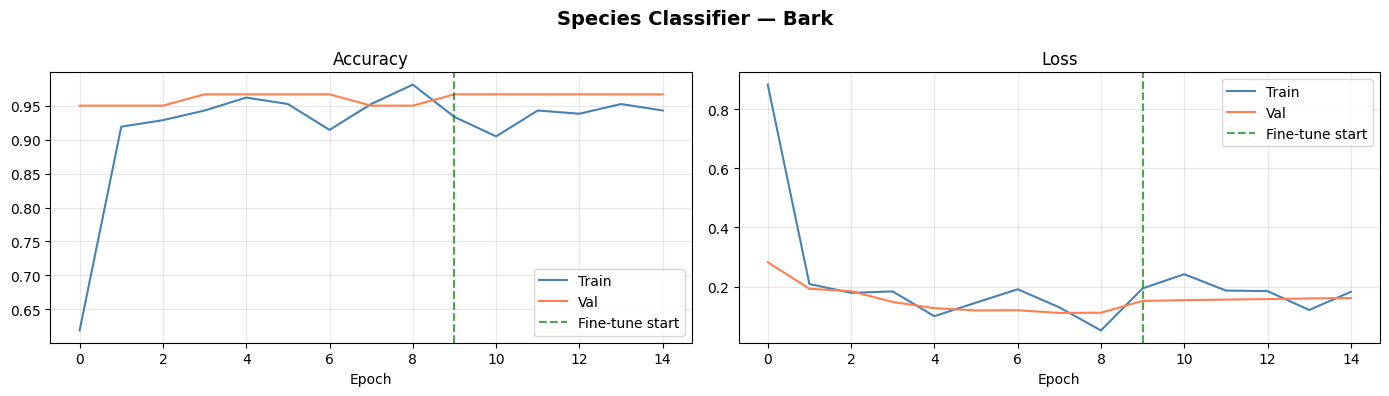

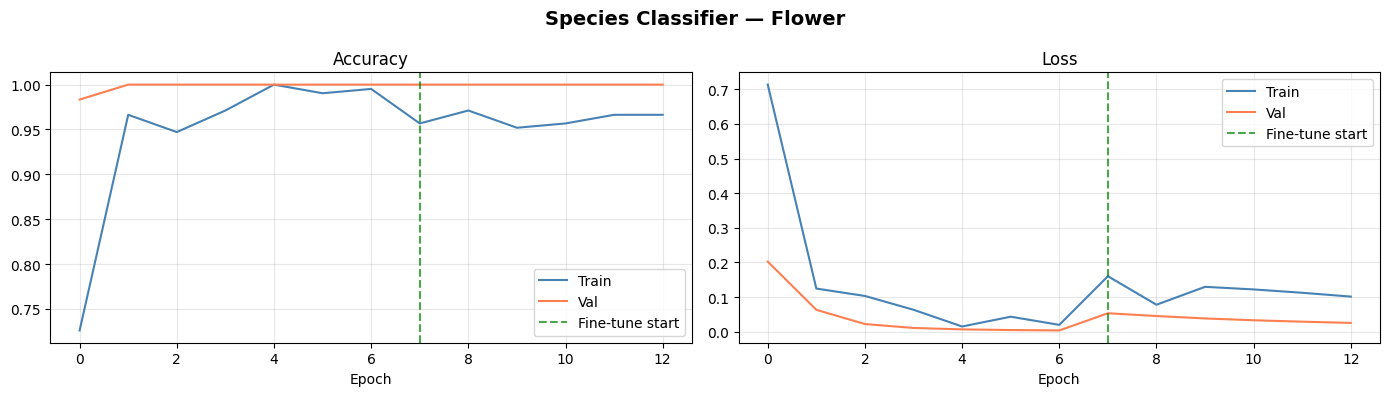

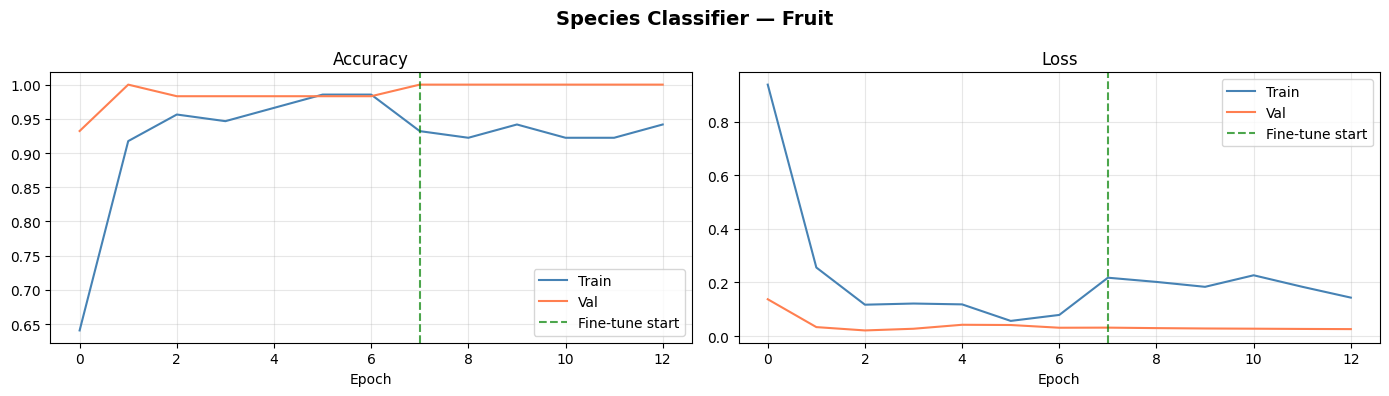

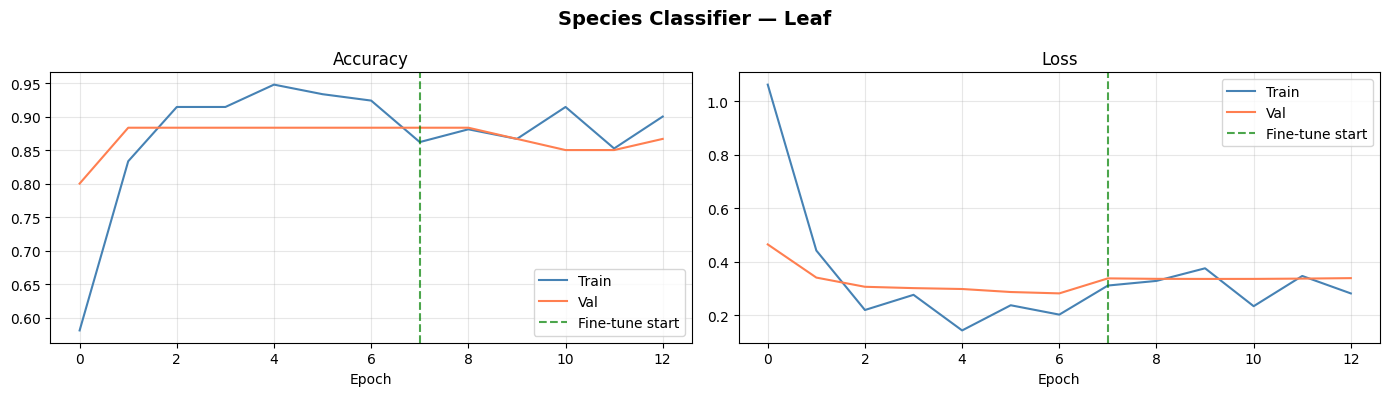

In [12]:
def plot_history(hist1, hist2, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Merge histories
    acc  = hist1.history['accuracy']  + hist2.history['accuracy']
    vacc = hist1.history['val_accuracy'] + hist2.history['val_accuracy']
    loss = hist1.history['loss'] + hist2.history['loss']
    vloss= hist1.history['val_loss'] + hist2.history['val_loss']
    stage2_start = len(hist1.history['accuracy'])

    for ax, metric, title_m in zip(axes, [(acc, vacc), (loss, vloss)], ['Accuracy', 'Loss']):
        m, vm = metric
        ax.plot(m,  label='Train', color='steelblue')
        ax.plot(vm, label='Val',   color='coral')
        ax.axvline(stage2_start, color='green', linestyle='--', alpha=0.7, label='Fine-tune start')
        ax.set_title(title_m); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# Part classifier
plot_history(part_hist1, part_hist2, 'Part Classifier (bark/flower/fruit/leaf)')

# Species classifiers
for part in PLANT_PARTS:
    h1, h2 = species_models[part]['hist']
    plot_history(h1, h2, f'Species Classifier — {part.capitalize()}')

## 🔍 Step 10: Confusion Matrices & Classification Reports

4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step


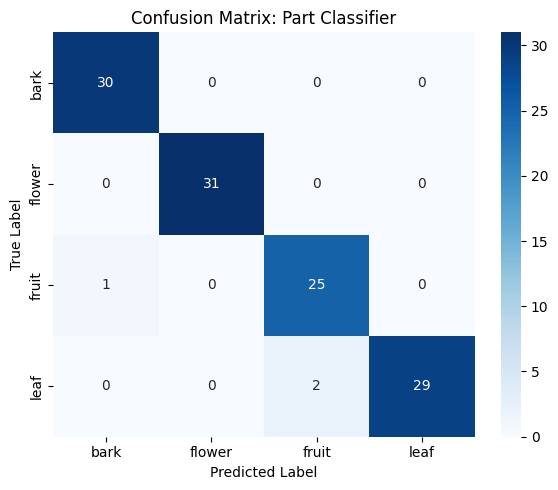

              precision    recall  f1-score   support

        bark       0.97      1.00      0.98        30
      flower       1.00      1.00      1.00        31
       fruit       0.93      0.96      0.94        26
        leaf       1.00      0.94      0.97        31

    accuracy                           0.97       118
   macro avg       0.97      0.97      0.97       118
weighted avg       0.98      0.97      0.97       118

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


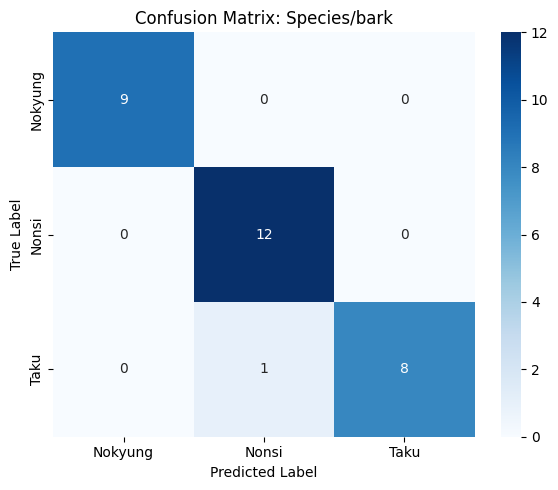

              precision    recall  f1-score   support

     Nokyung       1.00      1.00      1.00         9
       Nonsi       0.92      1.00      0.96        12
        Taku       1.00      0.89      0.94         9

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


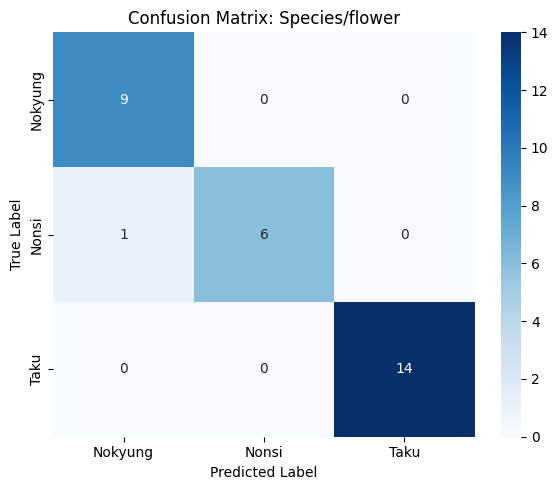

              precision    recall  f1-score   support

     Nokyung       0.90      1.00      0.95         9
       Nonsi       1.00      0.86      0.92         7
        Taku       1.00      1.00      1.00        14

    accuracy                           0.97        30
   macro avg       0.97      0.95      0.96        30
weighted avg       0.97      0.97      0.97        30



1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


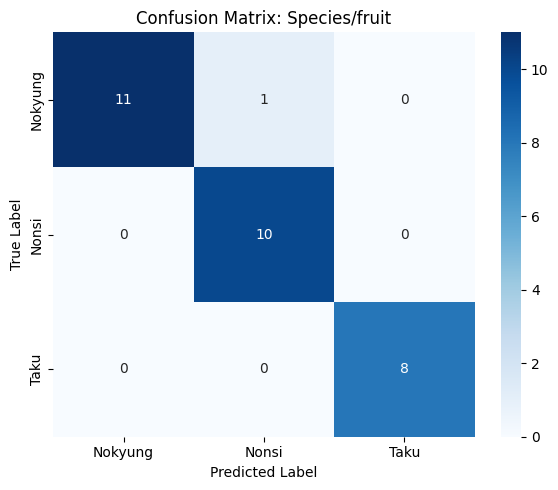

              precision    recall  f1-score   support

     Nokyung       1.00      0.92      0.96        12
       Nonsi       0.91      1.00      0.95        10
        Taku       1.00      1.00      1.00         8

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


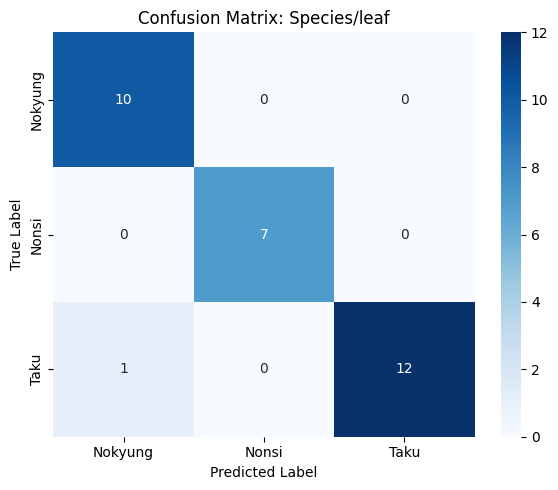

              precision    recall  f1-score   support

     Nokyung       0.91      1.00      0.95        10
       Nonsi       1.00      1.00      1.00         7
        Taku       1.00      0.92      0.96        13

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [13]:
def plot_confusion_matrix(model, test_gen, class_names, title):
    y_pred = np.argmax(model.predict(test_gen), axis=1)
    y_true = test_gen.classes

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix: {title}')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout(); plt.show()

    print(classification_report(y_true, y_pred, target_names=class_names))

# Part classifier
part_classes = [k for k, v in sorted(part_train.class_indices.items(), key=lambda x: x[1])]
plot_confusion_matrix(part_model, part_test, part_classes, 'Part Classifier')

# Species classifiers
for part in PLANT_PARTS:
    sp_classes = [k for k, v in sorted(species_gens[part]['train'].class_indices.items(), key=lambda x: x[1])]
    plot_confusion_matrix(
        species_models[part]['model'],
        species_gens[part]['test'],
        sp_classes,
        f'Species/{part}'
    )

## 🔮 Step 11: Hierarchical Prediction Pipeline

In [14]:
# Load class index maps
part_idx2name = {v: k for k, v in part_train.class_indices.items()}
species_idx2name = {}
for part in PLANT_PARTS:
    species_idx2name[part] = {v: k for k, v in species_gens[part]['train'].class_indices.items()}

def preprocess_image(img_path):
    img = Image.open(img_path).convert('RGB').resize(IMG_SIZE)
    arr = np.array(img, dtype=np.float32)
    arr = tf.keras.applications.mobilenet_v3.preprocess_input(arr)
    return np.expand_dims(arr, axis=0)

def predict_plant(img_path, confidence_threshold=0.5, verbose=True):
    """
    Hierarchical prediction:
    1) Predict plant part (bark/flower/fruit/leaf)
    2) Predict species using the matching part model

    Returns: dict with part, species, confidence scores
    """
    img = preprocess_image(img_path)

    # ── Step 1: Part prediction ───────────────
    part_probs = part_model.predict(img, verbose=0)[0]
    part_idx   = np.argmax(part_probs)
    part_name  = part_idx2name[part_idx]
    part_conf  = float(part_probs[part_idx])

    # ── Step 2: Species prediction ────────────
    sp_probs  = species_models[part_name]['model'].predict(img, verbose=0)[0]
    sp_idx    = np.argmax(sp_probs)
    sp_name   = species_idx2name[part_name][sp_idx]
    sp_conf   = float(sp_probs[sp_idx])

    result = {
        'part':          part_name,
        'part_conf':     part_conf,
        'part_probs':    {part_idx2name[i]: float(p) for i, p in enumerate(part_probs)},
        'species':       sp_name,
        'species_conf':  sp_conf,
        'species_probs': {species_idx2name[part_name][i]: float(p) for i, p in enumerate(sp_probs)},
        'low_confidence': part_conf < confidence_threshold or sp_conf < confidence_threshold
    }

    if verbose:
        print(f'🌿 Part     : {part_name} ({part_conf*100:.1f}%)')
        print(f'🌱 Species  : {sp_name} ({sp_conf*100:.1f}%)')
        if result['low_confidence']:
            print('⚠️  Low confidence — result may be unreliable')

    return result

print('✅ Prediction pipeline ready!')

✅ Prediction pipeline ready!


## 🖼️ Step 12: Test Prediction with Sample Images

🔍 Testing on sample images...

--- Sample: bark/Taku ---


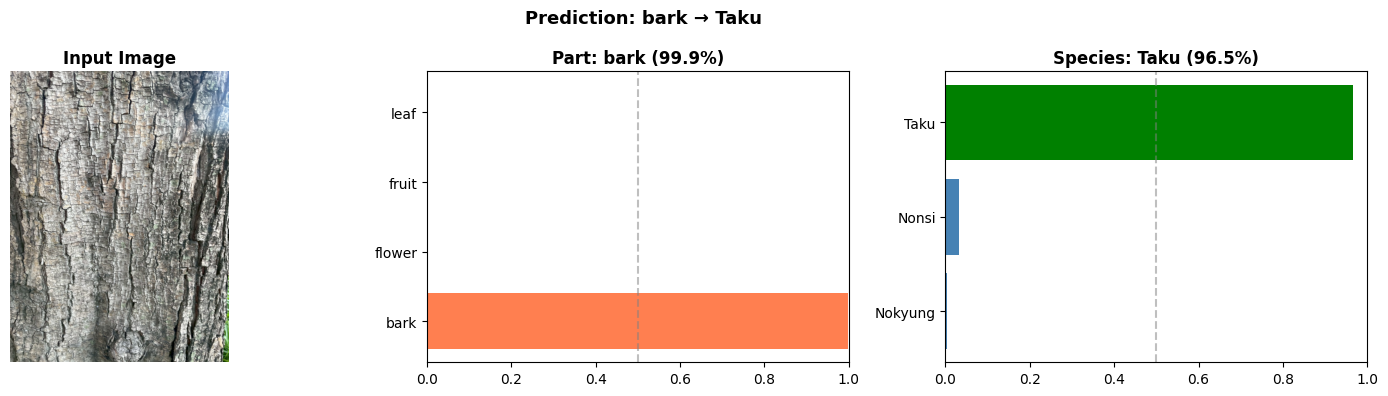

In [15]:
def visualize_prediction(img_path):
    result = predict_plant(img_path, verbose=False)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Original image
    img = Image.open(img_path).convert('RGB')
    axes[0].imshow(img)
    axes[0].set_title('Input Image', fontweight='bold')
    axes[0].axis('off')

    # Part probabilities
    parts   = list(result['part_probs'].keys())
    p_probs = list(result['part_probs'].values())
    colors  = ['steelblue' if p != result['part'] else 'coral' for p in parts]
    axes[1].barh(parts, p_probs, color=colors)
    axes[1].set_title(f'Part: {result["part"]} ({result["part_conf"]*100:.1f}%)', fontweight='bold')
    axes[1].set_xlim(0, 1)
    axes[1].axvline(0.5, color='gray', linestyle='--', alpha=0.5)

    # Species probabilities
    species  = list(result['species_probs'].keys())
    s_probs  = list(result['species_probs'].values())
    s_colors = ['steelblue' if s != result['species'] else 'green' for s in species]
    axes[2].barh(species, s_probs, color=s_colors)
    axes[2].set_title(f'Species: {result["species"]} ({result["species_conf"]*100:.1f}%)', fontweight='bold')
    axes[2].set_xlim(0, 1)
    axes[2].axvline(0.5, color='gray', linestyle='--', alpha=0.5)

    plt.suptitle(
        f'Prediction: {result["part"]} → {result["species"]}' +
        (' ⚠️ Low confidence' if result['low_confidence'] else ''),
        fontsize=13, fontweight='bold', color='red' if result['low_confidence'] else 'black'
    )
    plt.tight_layout()
    plt.show()
    return result

# Test on a few sample images from the test set
print('🔍 Testing on sample images...')
for part in PLANT_PARTS:
    test_dir = os.path.join(PREPARED_DIR, f'species_{part}', 'test')
    for sp in os.listdir(test_dir):
        sp_dir = os.path.join(test_dir, sp)
        imgs = [f for f in os.listdir(sp_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        if imgs:
            sample = os.path.join(sp_dir, imgs[0])
            print(f'\n--- Sample: {part}/{sp} ---')
            visualize_prediction(sample)
            break
    break  # Show only first part for demo — remove to show all

## 💾 Step 13: Save Model Info & Class Mappings

In [16]:
# Save class mappings for deployment
class_info = {
    'part_classes': part_train.class_indices,
    'species_classes': {part: species_gens[part]['train'].class_indices for part in PLANT_PARTS},
    'img_size': list(IMG_SIZE),
    'parts': PLANT_PARTS
}

with open(os.path.join(SAVE_DIR, 'class_mappings.json'), 'w') as f:
    json.dump(class_info, f, indent=2)

print('✅ Saved class_mappings.json')

# Summary table
print('\n' + '='*55)
print('  FINAL RESULTS SUMMARY')
print('='*55)
loss, acc = part_model.evaluate(part_test, verbose=0)
print(f'  Part Classifier Test Accuracy : {acc*100:.2f}%')
for part in PLANT_PARTS:
    print(f'  Species/{part:<8} Test Accuracy : {species_models[part]["test_acc"]*100:.2f}%')
print('='*55)

✅ Saved class_mappings.json

  FINAL RESULTS SUMMARY
  Part Classifier Test Accuracy : 97.46%
  Species/bark     Test Accuracy : 96.67%
  Species/flower   Test Accuracy : 96.67%
  Species/fruit    Test Accuracy : 96.67%
  Species/leaf     Test Accuracy : 96.67%


In [21]:
import os

SAVE_DIR = "models"
os.makedirs(SAVE_DIR, exist_ok=True)

# 🔹 Save part model
part_model.save(os.path.join(SAVE_DIR, "part_model.keras"))

# 🔹 Save species models
for part in PLANT_PARTS:
    species_models[part]['model'].save(
        os.path.join(SAVE_DIR, f"species_{part}.keras")
    )

print("✅ Saved all models (.keras)")

✅ Saved all models (.keras)


In [24]:
import json
import os

SAVE_DIR = "models"
os.makedirs(SAVE_DIR, exist_ok=True)

def invert_dict(d):
    return {v: k for k, v in d.items()}

class_info = {
    'part_classes': invert_dict(part_train.class_indices),
    'species_classes': {
        part: invert_dict(species_gens[part]['train'].class_indices)
        for part in PLANT_PARTS
    },
    'img_size': list(IMG_SIZE),
    'parts': PLANT_PARTS
}

with open(os.path.join(SAVE_DIR, 'class_mappings.json'), 'w') as f:
    json.dump(class_info, f, indent=2)

print("✅ Saved class_mappings.json")

✅ Saved class_mappings.json


In [25]:
import os

print(os.listdir())

['.config', 'drive', 'plant_data', 'models', 'sample_data']


## 🖼️ Step 14: Predict Your Own Image

📤 Upload an image to predict:


Saving download.jpg to download.jpg

Predicting: download.jpg


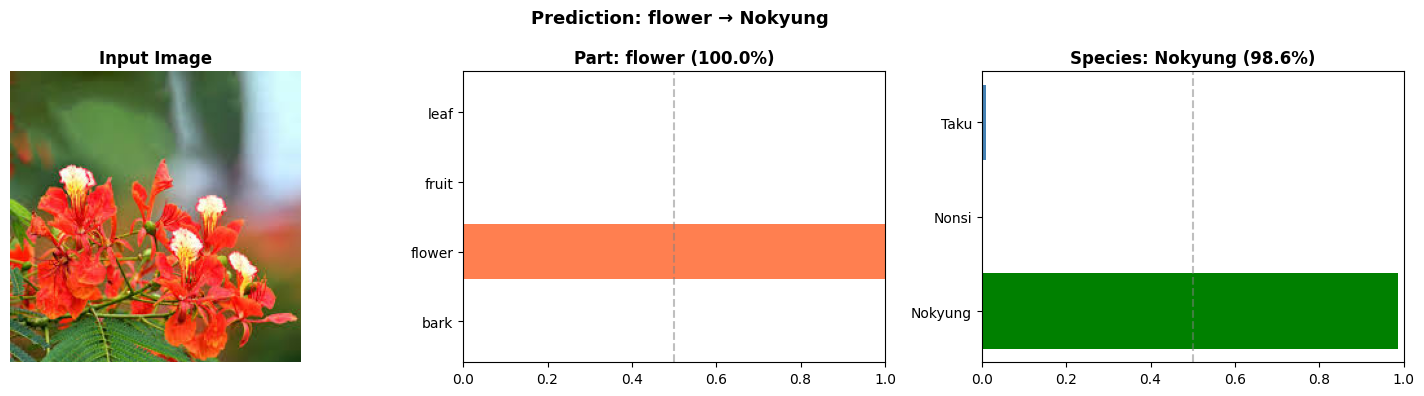

{
  "part": "flower",
  "part_conf": 0.9997920393943787,
  "part_probs": {
    "bark": 3.145032223983435e-06,
    "flower": 0.9997920393943787,
    "fruit": 6.298341759247705e-07,
    "leaf": 0.0002042874984908849
  },
  "species": "Nokyung",
  "species_conf": 0.9856321811676025,
  "species_probs": {
    "Nokyung": 0.9856321811676025,
    "Nonsi": 0.0033700515050441027,
    "Taku": 0.010997838340699673
  },
  "low_confidence": false
}


In [26]:
from google.colab import files

print('📤 Upload an image to predict:')
uploaded = files.upload()

for fname in uploaded.keys():
    print(f'\nPredicting: {fname}')
    result = visualize_prediction(fname)
    print(json.dumps(result, indent=2))


  Part Classifier
  ทำนายผิด: 3 / 118 รูป (2.5%)


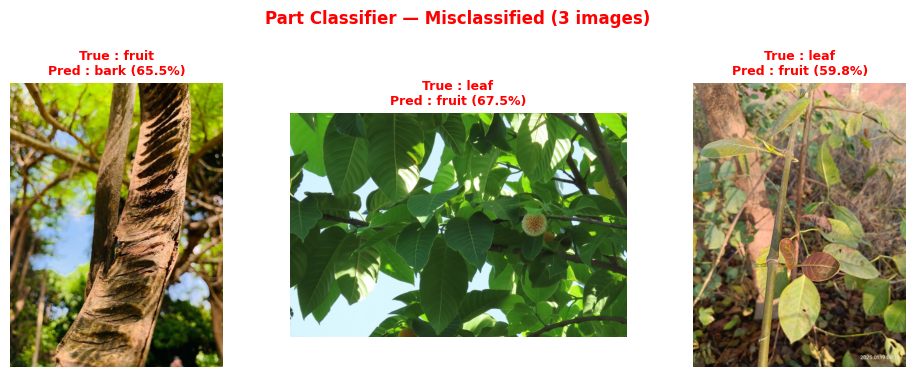


  Species Classifier — Bark
  ทำนายผิด: 1 / 30 รูป (3.3%)


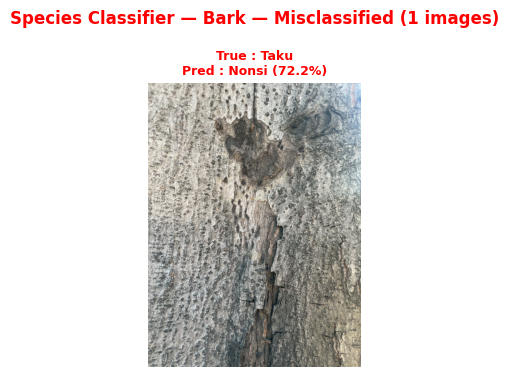


  Species Classifier — Flower
  ทำนายผิด: 1 / 30 รูป (3.3%)


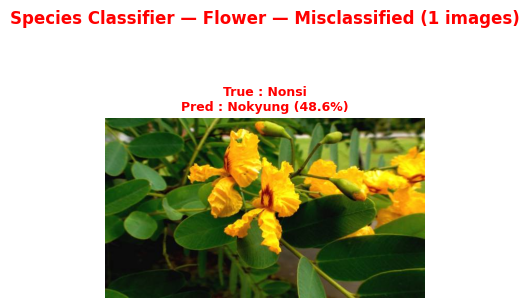


  Species Classifier — Fruit
  ทำนายผิด: 1 / 30 รูป (3.3%)


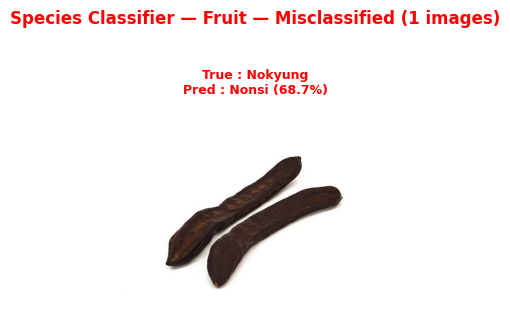


  Species Classifier — Leaf
  ทำนายผิด: 1 / 30 รูป (3.3%)


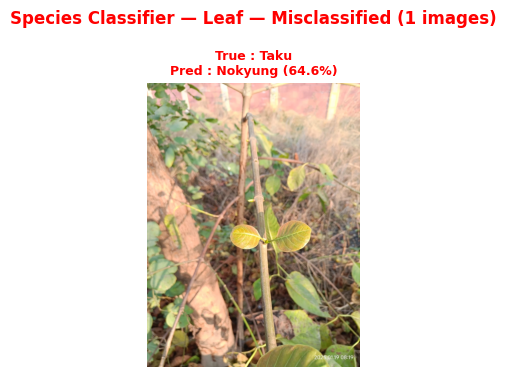

In [17]:
def show_misclassified(model, test_gen, idx2name, title, max_images=20):
    """
    แสดงรูปภาพที่โมเดลทำนายผิดพร้อม label จริง vs ที่ทำนาย
    """
    test_gen.reset()
    preds_prob = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(preds_prob, axis=1)
    y_true = test_gen.classes
    filenames = test_gen.filenames

    wrong_idx = np.where(y_pred != y_true)[0]
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"  ทำนายผิด: {len(wrong_idx)} / {len(y_true)} รูป "
          f"({len(wrong_idx)/len(y_true)*100:.1f}%)")
    print(f"{'='*60}")

    if len(wrong_idx) == 0:
        print("  ✅ ไม่มีรูปที่ทำนายผิดเลย!")
        return

    show_idx = wrong_idx[:max_images]
    n = len(show_idx)
    cols = min(5, n)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.8))
    axes = np.array(axes).reshape(-1) if n > 1 else [axes]

    data_dir = test_gen.directory

    for ax, idx in zip(axes, show_idx):
        img_path = os.path.join(data_dir, filenames[idx])
        img = Image.open(img_path).convert('RGB')

        true_label = idx2name[y_true[idx]]
        pred_label = idx2name[y_pred[idx]]
        conf       = preds_prob[idx][y_pred[idx]] * 100

        ax.imshow(img)
        ax.set_title(
            f"True : {true_label}\nPred : {pred_label} ({conf:.1f}%)",
            fontsize=9, color='red', fontweight='bold'
        )
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(2)
            spine.set_visible(True)

    for ax in axes[n:]:
        ax.axis('off')

    plt.suptitle(f"{title} — Misclassified ({n} images)", fontsize=12, fontweight='bold', color='red')
    plt.tight_layout()
    plt.show()


# ── Part Classifier ──────────────────────────────────────────
part_idx2name_local = {v: k for k, v in part_train.class_indices.items()}
show_misclassified(part_model, part_test, part_idx2name_local, "Part Classifier")

# ── Species Classifiers (แต่ละ part) ─────────────────────────
for part in PLANT_PARTS:
    sp_idx2name_local = {v: k for k, v in species_gens[part]['train'].class_indices.items()}
    show_misclassified(
        species_models[part]['model'],
        species_gens[part]['test'],
        sp_idx2name_local,
        f"Species Classifier — {part.capitalize()}"
    )

## 🔄 Step 15: Load Saved Models (Optional - For Later Use)

In [3]:
SAVE_DIR = '/content/drive/MyDrive/plant_models'

with open(os.path.join(SAVE_DIR, 'class_mappings.json'), 'r') as f:
    class_info = json.load(f)

part_model = tf.keras.models.load_model(os.path.join(SAVE_DIR, 'part_classifier_final.keras'))
species_models = {}
for part in PLANT_PARTS:
    model = tf.keras.models.load_model(os.path.join(SAVE_DIR, f'species_{part}_final.keras'))
    species_models[part] = {
        'model': model,
        'class_indices': class_info['species_classes'][part]
    }
part_idx2name = {v: k for k, v in class_info['part_classes'].items()}
species_idx2name = {part: {v: k for k,v in mp.items()} for part, mp in class_info['species_classes'].items()}
print('✅ All models loaded!')

NameError: name 'os' is not defined

In [18]:
import torch

# save weights
torch.save(model.state_dict(), "mobilenetv3.pth")

AttributeError: 'Functional' object has no attribute 'state_dict'

In [19]:
import torch
from torchvision import models

model = models.mobilenet_v3_large()
model.classifier[3] = torch.nn.Linear(1280, NUM_CLASSES)

model.load_state_dict(torch.load("mobilenetv3.pth", map_location="cpu"))
model.eval()

NameError: name 'NUM_CLASSES' is not defined